In [ ]:
!pip install torch torchvision numpy pandas opencv-python matplotlib efficientnet_pytorch

  Preparing metadata (setup.py) ... done
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.19.3-py3-none-manylinux1_x86_64.whl (166.0 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (99 kB)
  Using cached 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r "/content/drive/MyDrive/Replay_Attack_25April/bgr_signals.zip" /content
!cp -r "/content/drive/MyDrive/Replay_Attack_25April/last.zip" /content

In [ ]:
import os
!unzip /content/bgr_signals.zip -d /content/
os.remove("bgr_signals.zip")
!unzip /content/last.zip -d /content/
os.rename("last","dataset")
os.remove("last.zip")

Archive:  /content/bgr_signals.zip
   creating: /content/np_arrays/
   creating: /content/np_arrays/fake/
  inflating: /content/np_arrays/fake/38.npy  
  inflating: /content/np_arrays/fake/309.npy  
  inflating: /content/np_arrays/fake/81.npy  
  inflating: /content/np_arrays/fake/119.npy  
  inflating: /content/np_arrays/fake/155.npy  
  inflating: /content/np_arrays/fake/285.npy  
  inflating: /content/np_arrays/fake/128.npy  
  inflating: /content/np_arrays/fake/417.npy  
  inflating: /content/np_arrays/fake/31.npy  
  inflating: /content/np_arrays/fake/381.npy  
  inflating: /content/np_arrays/fake/271.npy  
  inflating: /content/np_arrays/fake/153.npy  
  inflating: /content/np_arrays/fake/131.npy  
  inflating: /content/np_arrays/fake/48.npy  
  inflating: /content/np_arrays/fake/59.npy  
  inflating: /content/np_arrays/fake/112.npy  
  inflating: /content/np_arrays/fake/459.npy  
  inflating: /content/np_arrays/fake/152.npy  
  inflating: /content/np_arrays/fake/7.npy  
  inflat

In [ ]:
import numpy as np
import os

# Assuming you're working in a directory containing 'np_arrays' folder
data_directory = '/content/np_arrays/fake/'  # Adjust path as needed
files = os.listdir(data_directory)

# Load the first file to see what's inside
sample_data = np.load(os.path.join(data_directory, files[0]))

# Display the shape or content of the data
print("Data Shape:", sample_data.shape)
print("Sample Data Content:", sample_data)

Data Shape: (30, 3)
Sample Data Content: [[2131969 1947610 2005852]
 [2137793 1959161 2016313]
 [2112330 1932751 1986501]
 [2111535 1940519 1992099]
 [2129862 1955354 2008958]
 [2113677 1943374 1991120]
 [2130216 1955056 2013130]
 [2133492 1958990 2019592]
 [2113983 1932767 1986596]
 [2127357 1956359 2012241]
 [2105381 1937858 1998083]
 [2126870 1945347 1986535]
 [2133539 1938700 1977304]
 [2148435 1958550 1999878]
 [2150096 1969392 2021675]
 [2133693 1960850 2011810]
 [2132183 1956609 2009333]
 [2128215 1950145 2003387]
 [2134722 1958607 2010091]
 [2127097 1939544 1991105]
 [2132643 1946405 1998741]
 [2142084 1960995 2016214]
 [2133610 1957669 2012097]
 [2123252 1952536 2006700]
 [2137960 1968117 2021606]
 [2132996 1950419 2004513]
 [2115592 1940111 1993110]
 [2125847 1939347 1991095]
 [2134741 1949011 2001795]
 [2120857 1951144 1998332]]


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset
import cv2
from skimage.transform import resize
import torch.nn as nn
import torch.nn.functional as F
import cv2
import glob
from PIL import Image
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, get_window
import torchvision.models as models

In [ ]:
# Brightness and contrast adjustments
alpha = 1.5
beta = 15
# Function to enhance the brightness and contrast of an image
def enhance_image(image):
    return cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
# end of the function


# Function to calculate chrom signal
def chrom(BGR_signal, fps, interval_length=None):
    num_frames = len(BGR_signal)
    if (num_frames == 0):
        raise NameError('EmptyData')
    if (fps < 9):
        raise NameError('WrongFPS')

    if (interval_length == None):
        interval_size = int(fps * (32.0 / 20.0))
    elif (interval_length > 0):
        interval_size = interval_length // 1
    else:
        raise NameError('WrongIntervalLength')

    if (num_frames < interval_size):
        raise NameError('NotEnoughData')

    R = BGR_signal[:, 2]
    G = BGR_signal[:, 1]
    B = BGR_signal[:, 0]

    def bandpass_filter(data, lowcut, highcut):
        fs = fps
        nyq = 0.5 * fs
        low = float(lowcut) / float(nyq)
        high = float(highcut) / float(nyq)
        order = 6.0
        b, a = butter(order, [low, high], btype='band')
        bandpass = lfilter(b, a, data)
        return bandpass

    def S_signal_on_interval(low_limit, high_limit):
        if (low_limit < 0.0):
            num_minus = abs(low_limit)
            R_interval = np.append(np.zeros(num_minus), R[0:high_limit + 1])
            R_interval_norm = R_interval / R_interval[num_minus:interval_size].mean()
            G_interval = np.append(np.zeros(num_minus), G[0:high_limit + 1])
            G_interval_norm = G_interval / G_interval[num_minus:interval_size].mean()
            B_interval = np.append(np.zeros(num_minus), B[0:high_limit + 1])
            B_interval_norm = B_interval / B_interval[num_minus:interval_size].mean()
        elif (high_limit > num_frames):
            num_plus = high_limit - num_frames
            R_interval = np.append(R[low_limit:num_frames], np.zeros(num_plus + 1))
            R_interval_norm = R_interval / R_interval[0:interval_size - num_plus - 1].mean()
            G_interval = np.append(G[low_limit:num_frames], np.zeros(num_plus + 1))
            G_interval_norm = G_interval / G_interval[0:interval_size - num_plus - 1].mean()
            B_interval = np.append(B[low_limit:num_frames], np.zeros(num_plus + 1))
            B_interval_norm = B_interval / B_interval[0:interval_size - num_plus - 1].mean()
        else:
            R_interval = R[low_limit:high_limit + 1]
            R_interval_norm = R_interval / R_interval.mean()
            G_interval = G[low_limit:high_limit + 1]
            G_interval_norm = G_interval / G_interval.mean()
            B_interval = B[low_limit:high_limit + 1]
            B_interval_norm = B_interval / B_interval.mean()
        Xs, Ys = np.zeros(interval_size), np.zeros(interval_size)
        Xs = 3.0 * R_interval_norm - 2.0 * G_interval_norm
        Ys = 1.5 * R_interval_norm + G_interval_norm - 1.5 * B_interval_norm
        Xf = bandpass_filter(Xs, 0.5, 4.0)
        Yf = bandpass_filter(Ys, 0.5, 4.0)
        alpha = Xf.std() / Yf.std()
        S_before = Xf - alpha * Yf

        return S_before

    number_interval = 2.0 * num_frames / interval_size + 1
    number_interval = int(number_interval // 1)
    intervals = []
    S_before_on_interval = []
    for i in range(int(number_interval)):
        i_low = int((i - 1) * interval_size / 2.0 + 1)
        i_high = int((i + 1) * interval_size / 2.0)
        intervals.append([i_low, i_high])
        S_before_on_interval.append(S_signal_on_interval(i_low, i_high))

    wh = get_window('hamming', interval_size)

    index_without_henning = []
    for i in range(intervals[0][0], intervals[1][0], 1):
        if (i >= 0):
            index_without_henning.append(i)
    for i in range(intervals[len(intervals) - 2][1] + 1, intervals[len(intervals) - 1][1], 1):
        if (i <= num_frames):
            index_without_henning.append(i)

    S_after = np.zeros(num_frames)
    for i in range(num_frames):
        for j in intervals:
            if (i >= j[0] and i <= j[1]):
                num_interval = intervals.index(j)
                num_element_on_interval = i - intervals[num_interval][0]
                if (i not in index_without_henning):
                    S_after[i] += S_before_on_interval[num_interval][num_element_on_interval] * wh[
                        num_element_on_interval]
                else:
                    S_after[i] += S_before_on_interval[num_interval][num_element_on_interval]

    return S_after


def extract_faces_frames(video_file,timesep,h,w):
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    vid_capture = cv2.VideoCapture(video_file)

    frames = []
    frames_count = 0
    while vid_capture.isOpened():
        return_TF, saved_frames = vid_capture.read()
        if not return_TF:
            break
        saved_frames = enhance_image(saved_frames)
        gray = cv2.cvtColor(saved_frames, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
        for i, (x, y, width, height) in enumerate(faces):
            # Extract ROI
            if frames_count == timesep:
              break
            roi = saved_frames[y:y+height, x:x+width]
            roi = cv2.resize(roi,(h,w))
            frames.append(roi)
            frames_count+=1

    vid_capture.release()
    return frames

def process_video(filename, timesep, h, w):
    frames = extract_faces_frames(filename, timesep, h, w)
    if len(frames) < 2048:  # Adjust the minimum required length as needed
        raise ValueError("Input signal is too short.")

    height = np.size(frames[0], 0)
    width = np.size(frames[0], 1)
    depth = np.size(frames[0], 2)
    reds = []
    greens = []
    blues = []
    for img in frames:
        height, width, _ = img.shape
        red_sum = 0
        green_sum = 0
        blue_sum = 0
        for i in range(height):
            for j in range(width):
                red_sum += img[i][j][0]
                green_sum += img[i][j][1]
                blue_sum += img[i][j][2]
        reds.append(red_sum)
        greens.append(green_sum)
        blues.append(blue_sum)
    BGR_signal = np.array([blues, greens, reds]).T
    return BGR_signal


import numpy as np
import librosa
import torch

In [ ]:
import os
print(os.path.exists('/content/dataset/fake/Mask_Half_1.mov'))  # Should return True or False

False


In [ ]:
import glob
import numpy
import os
os.mkdir("np_arrays")
os.mkdir("np_arrays/real")
os.mkdir("np_arrays/fake02")
for class_dir in glob.glob("dataset/*"):
  counter = 1
  print(class_dir)
  for video in glob.glob(class_dir+"/*"):
    try:
      BGR_signal = process_video(video,30,120,120)
    except:
      print(video)
      continue
    npy_path = os.path.join("np_arrays",class_dir.split("/")[-1],str(counter))
    np.save(npy_path, BGR_signal)
    counter+=1

!zip -r bgr_signals.zip np_arrays/
from google.colab import files
files.download('bgr_signals.zip')

FileExistsError: [Errno 17] File exists: 'np_arrays'

In [ ]:
import glob
import numpy as np

def chrom(BGR_signal, fps):
    # Dummy chrom function for demonstration; replace with your actual function.
    return np.mean(BGR_signal, axis=0)  # Simplified example of processing.

interrupted_videos = []
for class_dir in glob.glob("np_arrays/*"):
    print(f"Processing directory: {class_dir}")
    for video_path in glob.glob(class_dir + "/*"):
        print(f"Processing file: {video_path}")
        try:
            BGR_signal = np.load(video_path)
            rppg_signal = chrom(BGR_signal, 15)
            print("Successfully processed:", video_path)
        except Exception as e:
            print(f"Error processing {video_path}: {e}")
            interrupted_videos.append(video_path)

print("Interrupted videos:", interrupted_videos)

Processing directory: np_arrays/fake
Processing file: np_arrays/fake/275.npy
Successfully processed: np_arrays/fake/275.npy
Processing file: np_arrays/fake/41.npy
Successfully processed: np_arrays/fake/41.npy
Processing file: np_arrays/fake/358.npy
Successfully processed: np_arrays/fake/358.npy
Processing file: np_arrays/fake/214.npy
Successfully processed: np_arrays/fake/214.npy
Processing file: np_arrays/fake/480.npy
Successfully processed: np_arrays/fake/480.npy
Processing file: np_arrays/fake/439.npy
Successfully processed: np_arrays/fake/439.npy
Processing file: np_arrays/fake/168.npy
Successfully processed: np_arrays/fake/168.npy
Processing file: np_arrays/fake/450.npy
Successfully processed: np_arrays/fake/450.npy
Processing file: np_arrays/fake/338.npy
Successfully processed: np_arrays/fake/338.npy
Processing file: np_arrays/fake/20.npy
Successfully processed: np_arrays/fake/20.npy
Processing file: np_arrays/fake/117.npy
Successfully processed: np_arrays/fake/117.npy
Processing

In [ ]:
import os
for inter_video in interrupted_videos:
  os.remove(inter_video)

In [ ]:
import os
import pandas as pd

dataset_directory = "np_arrays"
class_names = os.listdir(dataset_directory)

data = []
for class_name in class_names:
    class_directory = os.path.join(dataset_directory, class_name)
    for filename in os.listdir(class_directory):
        if ".ipynb_checkpoints" in filename:
          continue
        filepath = os.path.join(class_directory, filename)
        label = 1 if class_name == 'fake' else 0
        data.append((filepath, label))

dataframe = pd.DataFrame(data, columns=['bgr_signal', 'label'])
# Now create the dataset
dataframe.head(1)


,bgr_signal,label
0,np_arrays/fake/275.npy,1


In [ ]:
import librosa

def preprocess_rppg_data(rppg_data, sample_rate=30, image_size=(120, 120), num_channels=3):
    spectrogram = librosa.feature.melspectrogram(y=rppg_data, sr=sample_rate)
    spectrogram_db = librosa.power_to_db(S=spectrogram, ref=np.max)
    repeated_spectrogram = np.repeat(spectrogram_db[np.newaxis, :, :], num_channels, axis=0)
    resized_spectrogram = torch.tensor(repeated_spectrogram[np.newaxis, :, :, :])
    resized_spectrogram = torch.nn.functional.interpolate(resized_spectrogram, size=image_size, mode='bicubic')

    return resized_spectrogram

In [ ]:
import cv2
import numpy as np
from scipy.signal import butter, lfilter, get_window

class VideoDataset(Dataset):
    def __init__(self, datas, timesep=39, h=120, w=120):
        self.dataloctions = datas
        self.timesep, self.h, self.w = timesep, h, w

    def __len__(self):
        return len(self.dataloctions)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        filename = self.dataloctions.iloc[idx, 0] # /content/np_arrays/fake/1.npy
        label = np.asarray(self.dataloctions.iloc[idx, 1]) # 1

        # Extract BGR signals from the video frames
        BGR_signal = np.load(filename)
        # Calculate rPPG signal using chrom function
        try:
            rppg_signal = chrom(BGR_signal, self.timesep//2)
            rppg_signal = preprocess_rppg_data(rppg_signal)
        except Exception as e:
            print(f"Error processing video {filename}: {e}")
        sample = {'rppg_signal': rppg_signal,
                  'label': torch.from_numpy(label)}

        return sample

In [ ]:
video_dataset = VideoDataset(dataframe)
print("Dataset Length: "+ str(video_dataset.__len__()))
sample = video_dataset.__getitem__(1)
sample

Dataset Length: 694


/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=3
  warnings.warn(


{'rppg_signal': tensor([[[[-1.2734e-04, -1.2734e-04, -1.2734e-04,  ..., -1.2734e-04,
            -1.2734e-04, -1.2734e-04],
           [-6.1485e-03, -6.1485e-03, -6.1485e-03,  ..., -6.1485e-03,
            -6.1485e-03, -6.1485e-03],
           [-1.6100e-02, -1.6100e-02, -1.6100e-02,  ..., -1.6100e-02,
            -1.6100e-02, -1.6100e-02],
           ...,
           [-9.2164e+00, -9.2164e+00, -9.2164e+00,  ..., -9.2164e+00,
            -9.2164e+00, -9.2164e+00],
           [-9.1878e+00, -9.1878e+00, -9.1878e+00,  ..., -9.1878e+00,
            -9.1878e+00, -9.1878e+00],
           [-9.1706e+00, -9.1706e+00, -9.1706e+00,  ..., -9.1706e+00,
            -9.1706e+00, -9.1706e+00]],
 
          [[-1.2734e-04, -1.2734e-04, -1.2734e-04,  ..., -1.2734e-04,
            -1.2734e-04, -1.2734e-04],
           [-6.1485e-03, -6.1485e-03, -6.1485e-03,  ..., -6.1485e-03,
            -6.1485e-03, -6.1485e-03],
           [-1.6100e-02, -1.6100e-02, -1.6100e-02,  ..., -1.6100e-02,
            -1.6100e-02,

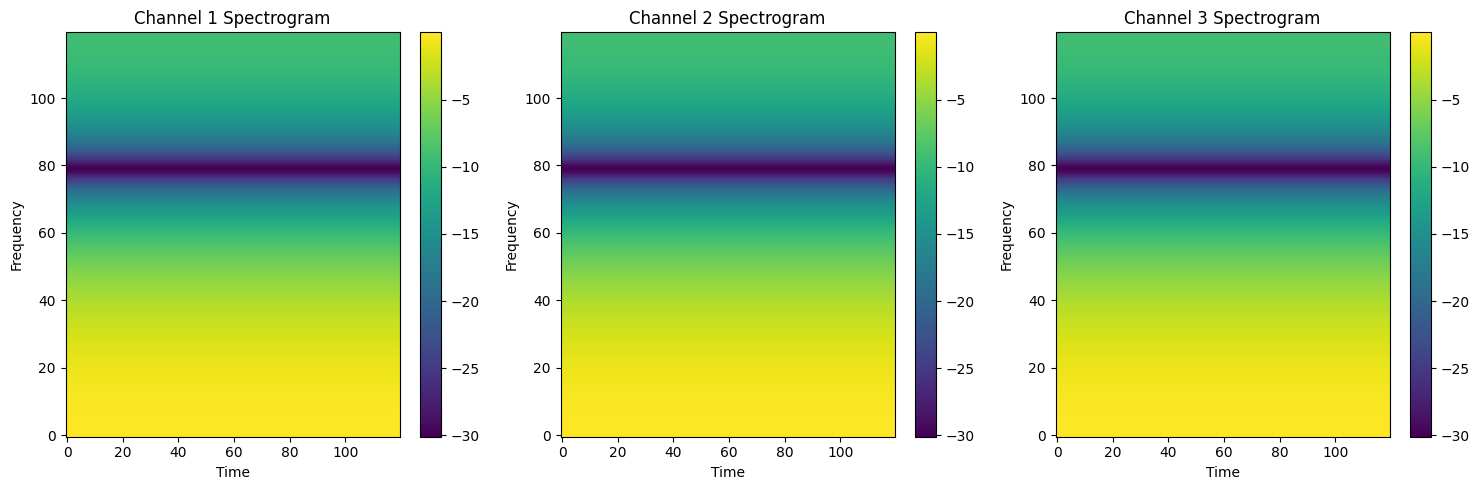

In [ ]:
def visualize_spectrogram(spectrogram):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    for i in range(3):  # Assuming the spectrogram has three channels
        ax = axs[i]
        img = ax.imshow(spectrogram[i], aspect='auto', origin='lower', cmap='viridis')
        fig.colorbar(img, ax=ax)
        ax.set_title(f'Channel {i+1} Spectrogram')
        ax.set_xlabel('Time')
        ax.set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# Assuming 'sample' is a valid sample from your dataset and its spectrogram has three channels
rppg_spectrogram = sample['rppg_signal'].squeeze().numpy()
visualize_spectrogram(rppg_spectrogram)

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

train_df, test_df = train_test_split(dataframe.sample(frac=1, random_state=42), test_size=0.3, random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=42)  # This will split the remaining 30% equally into 15% validation and 15% test

train_dataset = VideoDataset(train_df)
val_dataset = VideoDataset(val_df)
test_dataset = VideoDataset(test_df)

batch_size = 12

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print(f"Number of training samples: {len(train_loader.dataset)}")
print(f"Number of validation samples: {len(val_loader.dataset)}")
print(f"Number of test samples: {len(test_loader.dataset)}")

Number of training samples: 485
Number of validation samples: 104
Number of test samples: 105


In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [ ]:
import torch.nn as nn
import torchvision.models as models
from efficientnet_pytorch import EfficientNet

class EffecientForSVM(nn.Module):
    def __init__(self, num_classes, lstm_hidden_size=128, lstm_num_layers=1):
        super(EffecientForSVM, self).__init__()

        # Feature Extraction using efficient
        self.efficient_features = self._get_efficientnet_features()

        # LSTM layer
        self.lstm = nn.LSTM(input_size=1000, hidden_size=lstm_hidden_size,
                            num_layers=lstm_num_layers, batch_first=True)

    def forward(self, x):
        batch_size, time_steps, C, H, W = x.size()
        x = x.contiguous().view(batch_size * time_steps, C, H, W)
        x = self.efficient_features(x)
        # LSTM
        x = x.view(batch_size, -1, 1000)  # reshape to (batch_size, seq_length, features)
        _, (h_n, _) = self.lstm(x)
        # Take the last hidden state of the LSTM as the features
        lstm_output = h_n[-1, :, :]
        return lstm_output

    def _get_efficientnet_features(self):
      efficientnet = EfficientNet.from_pretrained('efficientnet-b0')
      return efficientnet

In [ ]:
num_classes = 2
model = EffecientForSVM(num_classes=num_classes)
model.to(device)
model

import torch.optim as optim
num_epochs = 25
criterion = nn.CrossEntropyLoss()

# optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for i, data in enumerate(train_loader, 0):
        optimizer.zero_grad()
        inputs, labels = data['rppg_signal'].to(device), data['label'].to(device)
        inputs = inputs.float()
        labels = labels.long()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Compute training statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)
        # print(loss.item())
    # Update learning rate
    # scheduler.step()

    # Print training statistics for each epoch
    epoch_loss = running_loss / total_samples
    accuracy = correct_predictions / total_samples
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {accuracy:.4f}")

print('Finished Training')

Loaded pretrained weights for efficientnet-b0
Epoch [1/25], Loss: 4.7577, Accuracy: 0.0247
Epoch [2/25], Loss: 4.4593, Accuracy: 0.3876
Epoch [3/25], Loss: 4.2882, Accuracy: 0.6928
Epoch [4/25], Loss: 4.2349, Accuracy: 0.7608
Epoch [5/25], Loss: 4.1888, Accuracy: 0.8165
Epoch [6/25], Loss: 4.1644, Accuracy: 0.8227
Epoch [7/25], Loss: 4.1418, Accuracy: 0.8309
Epoch [8/25], Loss: 4.1223, Accuracy: 0.8371
Epoch [9/25], Loss: 4.1093, Accuracy: 0.8454
Epoch [10/25], Loss: 4.1021, Accuracy: 0.8515
Epoch [11/25], Loss: 4.0903, Accuracy: 0.8495
Epoch [12/25], Loss: 4.0754, Accuracy: 0.8701
Epoch [13/25], Loss: 4.0633, Accuracy: 0.8763
Epoch [14/25], Loss: 4.0505, Accuracy: 0.8619
Epoch [15/25], Loss: 4.0480, Accuracy: 0.8412
Epoch [16/25], Loss: 4.0409, Accuracy: 0.8639
Epoch [17/25], Loss: 4.0312, Accuracy: 0.8660
Epoch [18/25], Loss: 4.0176, Accuracy: 0.8660
Epoch [19/25], Loss: 4.0062, Accuracy: 0.8392
Epoch [20/25], Loss: 4.0016, Accuracy: 0.8474
Epoch [21/25], Loss: 3.9917, Accuracy: 0.85

In [ ]:
from sklearn.metrics import accuracy_score

model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for data in val_loader:
        inputs, labels = data['rppg_signal'].to(device), data['label'].to(device)
        outputs = model(inputs.float())
        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

accuracy = accuracy_score(y_true, y_pred)
total = len(y_true)  # Calculate the total number of samples

print(f'Validation Accuracy: {100 * accuracy}%')


Validation Accuracy: 84.61538461538461%


In [ ]:
model.eval()
correct = 0
total = 0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Check if GPU is available
with torch.no_grad():
    for data in test_loader:
        inputs, labels = data['rppg_signal'].to(device), data['label'].to(device)  # Send data to the same device as the model
        outputs = model(inputs.float())
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the test videos: {100 * correct / total}%')


/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=3
  warnings.warn(


Accuracy of the network on the test videos: 87.61904761904762%


In [ ]:
import torch

# Path to the model weights file
weights_path = "/content/drive/MyDrive/trained_weight_replay.pth"

# Load the model weights
model_weights = torch.load(weights_path)

# Print the model weights
for name, param in model_weights.items():
    print(f"Layer: {name} | Size: {param.size()} | Values: \n{param}\n")

Streaming output truncated to the last 5000 lines.

Layer: efficient_features._blocks.10._se_reduce.weight | Size: torch.Size([28, 672, 1, 1]) | Values: 
tensor([[[[ 0.1110]],

         [[ 0.0415]],

         [[ 0.0124]],

         ...,

         [[ 0.0415]],

         [[ 0.0551]],

         [[-0.1691]]],


        [[[ 0.0460]],

         [[ 0.0249]],

         [[ 0.0667]],

         ...,

         [[ 0.0337]],

         [[-0.0205]],

         [[ 0.2408]]],


        [[[ 0.0352]],

         [[ 0.0871]],

         [[ 0.1089]],

         ...,

         [[ 0.0296]],

         [[-0.0021]],

         [[ 0.0811]]],


        ...,


        [[[-0.0788]],

         [[-0.1043]],

         [[-0.0600]],

         ...,

         [[ 0.0009]],

         [[-0.0241]],

         [[-0.0266]]],


        [[[ 0.0920]],

         [[ 0.0925]],

         [[-0.0987]],

         ...,

         [[-0.0123]],

         [[ 0.0408]],

         [[-0.0555]]],


        [[[-0.0219]],

         [[ 0.0627]],

         [

In [ ]:
# Define the path where you want to save the weights
weights_path = "/content/drive/MyDrive/trrained_weight_replay.pth"

# Save the weights of your trained model
torch.save(model.state_dict(), weights_path)

In [ ]:
import pickle

# Define the path where you want to save the training accuracy
accuracy_path_pickle = "/content/drive/MyDrive/trraining_accuracy_replay.pkl"

# Serialize the training accuracy using pickle
with open(accuracy_path_pickle, 'wb') as file:
    pickle.dump(accuracy, file)

In [ ]:
# Loading accuracy from a pickle file
with open(accuracy_path_pickle, 'rb') as file:
    loaded_accuracy_pickle = pickle.load(file)

In [ ]:
def process_video(filename, timesep, h, w, min_length=2048):
    frames = extract_faces_frames(filename, timesep, h, w)
    print(f"Extracted {len(frames)} frames from video.")

    # If not enough frames are extracted, pad the list with the last frame
    while len(frames) < min_length:
        if frames:
            frames.append(frames[-1])
        else:
            raise ValueError("No frames could be extracted from the video.")

    height, width, _ = frames[0].shape
    BGR_signal = []

    for img in frames:
        red_sum = np.sum(img[:,:,2])
        green_sum = np.sum(img[:,:,1])
        blue_sum = np.sum(img[:,:,0])
        BGR_signal.append([blue_sum, green_sum, red_sum])

    BGR_signal = np.array(BGR_signal)
    return BGR_signal

In [ ]:
def extract_faces_frames(video_file, timesep, h, w):
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    vid_capture = cv2.VideoCapture(video_file)

    if not vid_capture.isOpened():
        raise ValueError(f"Failed to open video file {video_file}")

    frames = []
    frames_count = 0
    while vid_capture.isOpened():
        ret, frame = vid_capture.read()
        if not ret:
            break
        frame = enhance_image(frame)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.05, minNeighbors=3, minSize=(30, 30))

        # Debug: Visualize/Display frame with detected faces
        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)

        if faces.any():
            for (x, y, width, height) in faces:
                if frames_count >= timesep:
                    break
                roi = frame[y:y+height, x:x+width]
                roi = cv2.resize(roi, (h, w))
                frames.append(roi)
                frames_count += 1
            if frames_count >= timesep:
                break
        else:
            print("No faces detected in this frame.")

    vid_capture.release()

    if not frames:
        print("No faces detected in the video.")
    else:
        print(f"Extracted {len(frames)} faces from the video.")

    return frames


In [ ]:
def test_video_read(video_file):
    vid_capture = cv2.VideoCapture(video_file)
    if not vid_capture.isOpened():
        print("Cannot open video.")
        return
    count = 0
    while True:
        ret, frame = vid_capture.read()
        if not ret:
            break
        if count < 5:  # Save or display first 5 frames
            cv2.imwrite(f"frame_{count}.jpg", frame)
        count += 1
    vid_capture.release()
    print(f"Total frames read: {count}")

test_video_read("/content/dataset/fake/attack_highdef_client001_session01_highdef_photo_adverse.mov")

Total frames read: 240


In [ ]:
def extract_faces_frames(video_file, timesep, h, w):
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    vid_capture = cv2.VideoCapture(video_file)
    if not vid_capture.isOpened():
        raise ValueError(f"Failed to open video file {video_file}")

    frames = []
    frames_count = 0
    debug_frame_count = 0

    while vid_capture.isOpened():
        ret, frame = vid_capture.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
        if len(faces) == 0:
            cv2.imwrite(f"debug_no_face_{debug_frame_count}.jpg", frame)  # Save frames without detected faces
            debug_frame_count += 1
        else:
            for (x, y, width, height) in faces:
                if frames_count >= timesep:
                    break
                roi = frame[y:y+height, x:x+width]
                roi = cv2.resize(roi, (h, w))
                frames.append(roi)
                frames_count += 1
        if frames_count >= timesep:
            break

    vid_capture.release()
    print(f"Total frames captured: {len(frames)}, Debug frames saved: {debug_frame_count}")
    return frames


In [ ]:
def load_model(wegiths_path):
  num_classes = 2
  model = EffecientForSVM(num_classes=num_classes)
  model.to(device)
  model.load_state_dict(torch.load(wegiths_path,map_location=torch.device(device)))
  model.eval()
  return model

model = load_model(weights_path)

def get_lstm_features(model, video_path):
    bgr_signal = process_video(video_path, timesep=30, h=120, w=120)
    rppg = chrom(bgr_signal,15)
    rppg_signal = preprocess_rppg_data(rppg).unsqueeze(0)

    outputs = model(rppg_signal.float().to(device))
    return outputs.squeeze()

get_lstm_features(model, "/content/dataset/fake/attack_highdef_client001_session01_highdef_photo_adverse.mov")

Loaded pretrained weights for efficientnet-b0
Total frames captured: 30, Debug frames saved: 0
Extracted 30 frames from video.


tensor([ 7.6146e-01,  3.3653e-02, -4.9577e-01,  1.0464e-01, -6.2604e-01,
        -1.3993e-01, -1.2002e-03, -3.8693e-01, -6.3636e-01, -8.8635e-03,
        -5.3505e-03, -4.6332e-01, -5.3208e-03, -5.4626e-02,  1.5087e-02,
        -6.9840e-01,  2.7773e-02, -7.5704e-01, -5.1826e-01,  3.5407e-03,
         1.6675e-02,  2.9958e-03, -7.1162e-01,  8.8962e-02,  1.1566e-02,
         3.2710e-02,  2.2801e-02, -4.5434e-01,  2.3810e-04,  3.7139e-01,
        -3.4347e-01, -5.9917e-01,  4.0476e-03, -2.1685e-02,  1.4308e-03,
         3.3493e-04, -4.3088e-02,  3.2731e-04, -5.6628e-01,  7.5258e-04,
        -6.0287e-01, -4.4642e-01, -6.2542e-01,  8.1882e-04, -1.9046e-01,
        -5.6614e-01, -1.8236e-02,  8.3836e-03,  7.9870e-03, -1.0611e-04,
        -2.6358e-01, -1.2075e-02, -7.2303e-01, -6.8057e-01,  4.0939e-02,
        -1.3589e-01,  6.0497e-03,  4.8196e-03,  2.4011e-02,  1.6798e-03,
         1.5019e-01, -1.6874e-01,  4.4300e-03,  2.1574e-04, -6.4180e-01,
        -1.5792e-02, -2.9363e-01,  8.8165e-03,  1.1

In [ ]:
import pandas as pd
import numpy as np

def get_lstm_features_and_labels(df):
    lstm_data = {'features': [], 'label': []}

    for index, row in df.iterrows():
        np_path = row['bgr_signal']
        label = row['label']

        np_array = np.load(np_path)
        rppg = chrom(np_array, 15)
        rppg = preprocess_rppg_data(rppg)
        rppg_signal = rppg.unsqueeze(0)

        # Move the input tensor to the same device as the model
        rppg_signal = rppg_signal.float().to(device)

        # Perform inference using the model
        with torch.no_grad():
            lstm_features = model(rppg_signal).squeeze().cpu().numpy()  # Move tensor to CPU before converting to numpy array

        lstm_data['features'].append(lstm_features)
        lstm_data['label'].append(label)

    return lstm_data

lstm_data = get_lstm_features_and_labels(dataframe)

lstm_df = pd.DataFrame(lstm_data)

lstm_df.to_csv('lstm_features_and_labels.csv', index=False)


In [ ]:
lstm_features_csv = pd.read_csv("lstm_features_and_labels.csv")
lstm_features_csv.head(3)

,features,label
0,[-3.19805531e-06 7.61415660e-01 -6.38620630e-...,1
1,[-2.1606793e-06 7.6077569e-01 1.0074079e-01 ...,1
2,[-8.95208286e-05 7.59289145e-01 -3.56087647e-...,1


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class DenseNetClassifier(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super(DenseNetClassifier, self).__init__()
        self.densenet = models.densenet121(pretrained=pretrained)
        num_ftrs = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        batch_size, time_steps, C, H, W = x.size()
        x = x.contiguous().view(batch_size * time_steps, C, H, W)
        return self.densenet(x)

In [ ]:
def pre_process_lstm_features(lstm_features):
    spectrogram = librosa.feature.melspectrogram(y=lstm_features, sr=128)
    spectrogram_db = librosa.power_to_db(S=spectrogram, ref=np.max)
    repeated_spectrogram = np.repeat(spectrogram_db[np.newaxis, :, :], 3, axis=0)
    resized_spectrogram = torch.tensor(repeated_spectrogram[np.newaxis, :, :, :])
    resized_spectrogram = torch.nn.functional.interpolate(resized_spectrogram, size=(120,120), mode='bicubic')

    return resized_spectrogram

In [ ]:
import cv2
import numpy as np
from scipy.signal import butter, lfilter, get_window

class LstmFeaturesDLDataset(Dataset):
    def __init__(self, datas):
        self.dataloctions = datas

    def __len__(self):
        return len(self.dataloctions)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        features = self.dataloctions.iloc[idx, 0]
        features = features.replace("[","").replace("]","").split()
        features = [float(feature) for feature in features]
        features = np.array(features)
        features = pre_process_lstm_features(features) #
        label = np.asarray(self.dataloctions.iloc[idx, 1])

        sample = {'features': features,
                  'label': torch.from_numpy(label)}

        return sample

In [ ]:
lstm_dataset = LstmFeaturesDLDataset(lstm_features_csv)
print(lstm_dataset.__len__())
sample = lstm_dataset.__getitem__(0)
print(sample)

694
{'features': tensor([[[[ -0.2423,  -0.2423,  -0.2423,  ...,  -0.2423,  -0.2423,  -0.2423],
          [ -9.7431,  -9.7431,  -9.7431,  ...,  -9.7431,  -9.7431,  -9.7431],
          [ -8.1397,  -8.1397,  -8.1397,  ...,  -8.1397,  -8.1397,  -8.1397],
          ...,
          [-23.2024, -23.2024, -23.2024,  ..., -23.2024, -23.2024, -23.2024],
          [-27.9079, -27.9079, -27.9079,  ..., -27.9079, -27.9079, -27.9079],
          [-23.1500, -23.1500, -23.1500,  ..., -23.1500, -23.1500, -23.1500]],

         [[ -0.2423,  -0.2423,  -0.2423,  ...,  -0.2423,  -0.2423,  -0.2423],
          [ -9.7431,  -9.7431,  -9.7431,  ...,  -9.7431,  -9.7431,  -9.7431],
          [ -8.1397,  -8.1397,  -8.1397,  ...,  -8.1397,  -8.1397,  -8.1397],
          ...,
          [-23.2024, -23.2024, -23.2024,  ..., -23.2024, -23.2024, -23.2024],
          [-27.9079, -27.9079, -27.9079,  ..., -27.9079, -27.9079, -27.9079],
          [-23.1500, -23.1500, -23.1500,  ..., -23.1500, -23.1500, -23.1500]],

         [[ -

/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=128
  warnings.warn(


In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

train_df, test_df = train_test_split(dataframe.sample(frac=1, random_state=42), test_size=0.3, random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=42)  # This will split the remaining 30% equally into 15% validation and 15% test

train_dataset = VideoDataset(train_df)
val_dataset = VideoDataset(val_df)
test_dataset = VideoDataset(test_df)

batch_size = 12

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print(f"Number of training samples: {len(train_loader.dataset)}")
print(f"Number of validation samples: {len(val_loader.dataset)}")
print(f"Number of test samples: {len(test_loader.dataset)}")

Number of training samples: 485
Number of validation samples: 104
Number of test samples: 105


In [ ]:
import torch.optim as optim

model = DenseNetClassifier(num_classes=2).to(device)

num_epochs = 50
model.train()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

for epoch in range(num_epochs):
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for i, data in enumerate(train_loader, 0):
        optimizer.zero_grad()
        inputs, labels = data['rppg_signal'].to(device), data['label'].to(device)
        inputs = inputs.float().to(device)
        labels = labels.long().to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)
    epoch_loss = running_loss / total_samples
    accuracy = correct_predictions / total_samples
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {accuracy:.4f}")


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/50], Loss: 0.4374, Accuracy: 0.8062
Epoch [2/50], Loss: 0.3263, Accuracy: 0.8598
Epoch [3/50], Loss: 0.2954, Accuracy: 0.8557
Epoch [4/50], Loss: 0.2989, Accuracy: 0.8680
Epoch [5/50], Loss: 0.3182, Accuracy: 0.8598
Epoch [6/50], Loss: 0.3010, Accuracy: 0.8639
Epoch [7/50], Loss: 0.2753, Accuracy: 0.8763
Epoch [8/50], Loss: 0.2640, Accuracy: 0.8845
Epoch [9/50], Loss: 0.2866, Accuracy: 0.8763
Epoch [10/50], Loss: 0.2731, Accuracy: 0.8866
Epoch [11/50], Loss: 0.2983, Accuracy: 0.8433
Epoch [12/50], Loss: 0.2826, Accuracy: 0.8557
Epoch [13/50], Loss: 0.2747, Accuracy: 0.8887
Epoch [14/50], Loss: 0.2634, Accuracy: 0.8784
Epoch [15/50], Loss: 0.2646, Accuracy: 0.8784
Epoch [16/50], Loss: 0.2612, Accuracy: 0.8825
Epoch [17/50], Loss: 0.2488, Accuracy: 0.8866
Epoch [18/50], Loss: 0.3020, Accuracy: 0.8660
Epoch [19/50], Loss: 0.3178, Accuracy: 0.8639
Epoch [20/50], Loss: 0.2854, Accuracy: 0.8804
Epoch [21/50], Loss: 0.2788, Accuracy: 0.8825
Epoch [22/50], Loss: 0.2675, Accuracy: 0.88

In [ ]:
    model.eval()
    validation_loss = 0.0
    correct_val_predictions = 0
    total_val_samples = 0
    for data in val_loader:
        inputs, labels = data['rppg_signal'].to(device), data['label'].to(device)
        inputs = inputs.float()
        labels = labels.long()
        outputs = model(inputs)
        val_loss = criterion(outputs, labels)
        validation_loss += val_loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_val_predictions += (predicted == labels).sum().item()
        total_val_samples += labels.size(0)

    val_accuracy = correct_val_predictions / total_val_samples
    val_epoch_loss = validation_loss / total_val_samples
    print(f'Validation - Epoch [{epoch+1}/{num_epochs}], Loss: {val_epoch_loss:.4f}, Accuracy: {val_accuracy:.4f}')

Validation - Epoch [50/50], Loss: 0.2610, Accuracy: 0.8942


In [ ]:
from torch.utils.data import DataLoader
# Assuming your test dataset is prepared in a similar manner to your training dataset
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
model.eval()  # Set the model to evaluation mode
test_loss = 0.0
correct_predictions = 0
total_samples = 0

# Disable gradient calculations since they're not needed for testing
with torch.no_grad():
    for data in test_loader:
        inputs, labels = data['rppg_signal'].to(device), data['label'].to(device)
        inputs = inputs.float()
        labels = labels.long()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)

# Calculate average losses and total accuracy
test_loss /= total_samples
test_accuracy = correct_predictions / total_samples

print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

Test Loss: 0.2776, Test Accuracy: 0.9143


In [ ]:
from sklearn.metrics import accuracy_score

model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for data in val_loader:
        inputs, labels = data['rppg_signal'].to(device), data['label'].to(device)
        outputs = model(inputs.float())
        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

accuracy = accuracy_score(y_true, y_pred)
total = len(y_true)  # Calculate the total number of samples

print(f'Val Accuracy: {100 * accuracy}%')

Val Accuracy: 89.42307692307693%


In [ ]:
model.eval()
correct = 0
total = 0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Check if GPU is available
with torch.no_grad():
    for data in test_loader:
        inputs, labels = data['rppg_signal'].to(device), data['label'].to(device)  # Send data to the same device as the model
        outputs = model(inputs.float())
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the test videos: {100 * correct / total}%')

/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=3
  warnings.warn(


Accuracy of the network on the test videos: 91.42857142857143%


In [ ]:
# Define the path where you want to save the weights
weights_path_densenet = "/content/drive/MyDrive/ttrained_weights_densenet.pth"

# Save the weights of your trained model
torch.save(model.state_dict(), weights_path_densenet)

In [ ]:
import pickle

# Define the path where you want to save the training accuracy using pickle
accuracy_path_densenet_pickle = "/content/drive/MyDrive/ttraining_accuracy_densenet.pkl"

# Assume this is the training accuracy you have obtained from your DenseNet model
accuracy = 92.31  # example accuracy percentage, ensure this value is defined

# Serialize the training accuracy using pickle
with open(accuracy_path_densenet_pickle, 'wb') as file:
    pickle.dump(accuracy, file)


In [ ]:
pip install numpy scikit-learn matplotlib

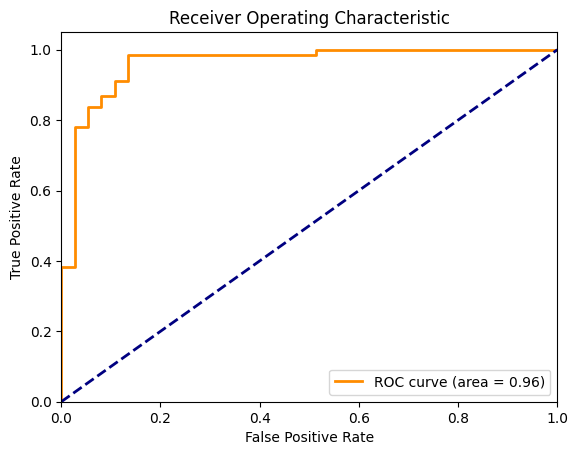

In [ ]:
import torch
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Ensure the model is in evaluation mode
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# List to hold probabilities and true labels
probs = []
true_labels = []

with torch.no_grad():
    for data in test_loader:
        inputs, labels = data['rppg_signal'].to(device), data['label'].to(device)
        inputs = inputs.float()  # Ensure inputs are in Float type to match model weights
        outputs = model(inputs)

        # Softmax on outputs to get probabilities
        probabilities = torch.nn.functional.softmax(outputs, dim=1)[:, 1].cpu().numpy()  # Probabilities for the 'fake=1' class
        probs.extend(probabilities)
        true_labels.extend(labels.cpu().numpy())

# Converting lists to numpy arrays for use with sklearn metrics
probs = np.array(probs)
true_labels = np.array(true_labels)

# Calculate ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(true_labels, probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

EER: 0.10810810810810811
HTER: 0.0981717011128776


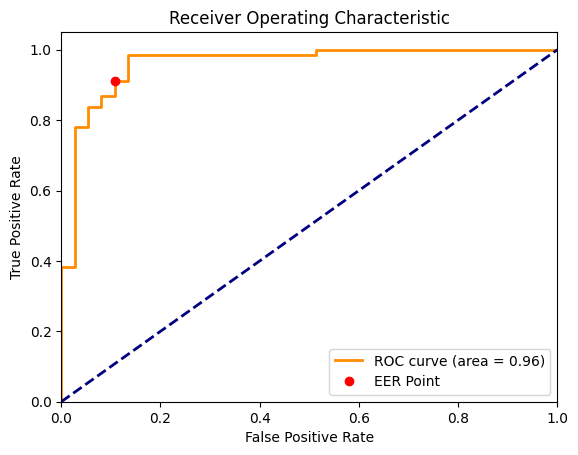

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(true_labels, probs)
roc_auc = auc(fpr, tpr)

# EER
fnr = 1 - tpr
# Minimum point where the absolute difference between FNR and FPR is minimized
eer_threshold_index = np.nanargmin(np.abs(fnr - fpr))
EER = fpr[eer_threshold_index]

# HTER at the EER threshold
HTER = (fpr[eer_threshold_index] + fnr[eer_threshold_index]) / 2

# Print the EER and HTER
print("EER:", EER)
print("HTER:", HTER)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.plot(fpr[eer_threshold_index], tpr[eer_threshold_index], 'ro', label='EER Point')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [ ]:
'''import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Calculating EER
fnr = 1 - tpr
eer_threshold = thresholds[np.nanargmin(np.absolute((fnr - fpr)))]
EER = fpr[np.nanargmin(np.absolute((fnr - fpr)))]
print("EER:", EER)

# Calculate HTER
HTER = (EER + (1 - tpr[np.nanargmin(np.absolute((fnr - fpr)))])) / 2
print("HTER:", HTER)

ValueError: Found input variables with inconsistent numbers of samples: [104, 105]

In [ ]:
pip install seaborn

In [ ]:
# evaluation mode
model.eval()

# Containers for predictions and actual labels
true_labels = []
predicted_labels = []

# Disable gradient calculations
with torch.no_grad():
    for data in test_loader:
        inputs = data['rppg_signal'].to(device)  # Assuming your data has a key 'rppg_signal'
        labels = data['label'].to(device)  # Assuming your data has a key 'label'

        # Forward pass
        outputs = model(inputs.float())
        _, predictions = torch.max(outputs, 1)

        # Collect the true labels and predictions
        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predictions.cpu().numpy())

# Now we FINALLY have 'true_labels' and 'predicted_labels' lists filled with data

/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=3
  warnings.warn(


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Calculate the confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)
print("Confusion Matrix:\n", conf_matrix)

# Calculate the accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[29  8]
 [ 1 67]]
Accuracy: 0.9142857142857143


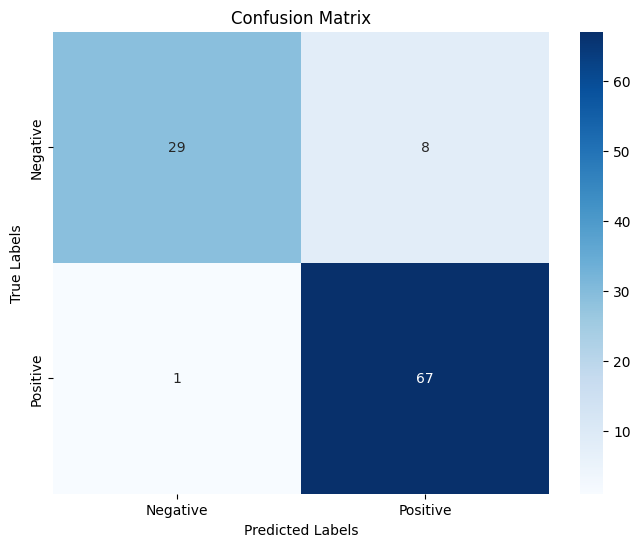

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Assuming 'true_labels' and 'predicted_labels' are available from your previous model evaluation
report = classification_report(true_labels, predicted_labels, target_names=['Negative', 'Positive'])
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

    Negative       0.97      0.78      0.87        37
    Positive       0.89      0.99      0.94        68

    accuracy                           0.91       105
   macro avg       0.93      0.88      0.90       105
weighted avg       0.92      0.91      0.91       105



In [ ]:
report = classification_report(true_labels, predicted_labels, target_names=['Negative', 'Positive'], zero_division=1)
print("Classification Report with Weighted Scores:\n", report)

Classification Report with Weighted Scores:
               precision    recall  f1-score   support

    Negative       0.97      0.78      0.87        37
    Positive       0.89      0.99      0.94        68

    accuracy                           0.91       105
   macro avg       0.93      0.88      0.90       105
weighted avg       0.92      0.91      0.91       105



In [ ]:
report = classification_report(true_labels, predicted_labels, target_names=['Negative', 'Positive'], zero_division=0)
print(report)

              precision    recall  f1-score   support

    Negative       0.97      0.78      0.87        37
    Positive       0.89      0.99      0.94        68

    accuracy                           0.91       105
   macro avg       0.93      0.88      0.90       105
weighted avg       0.92      0.91      0.91       105



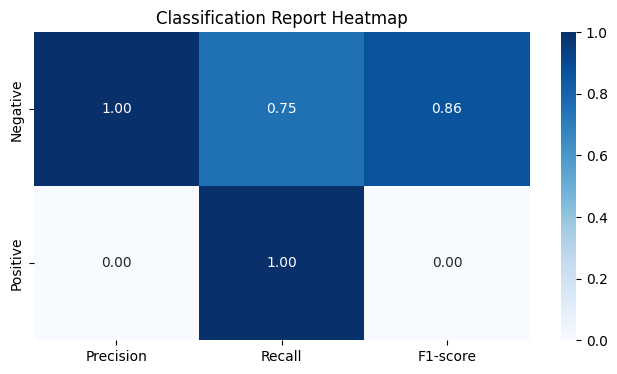

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Manually creating a DataFrame from your provided data
data = {
    'Precision': [1.00, 0.00],
    'Recall': [0.75, 1.00],
    'F1-score': [0.86, 0.00],
    'Support': [4, 0]
}

index = ['Negative', 'Positive']
df = pd.DataFrame(data, index=index)

# Plotting
plt.figure(figsize=(8, 4))
sns.heatmap(df.drop('Support', axis=1), annot=True, cmap='Blues', fmt=".2f")
plt.title('Classification Report Heatmap')
plt.show()

In [ ]:
'''# Example counts
TN = 3  # True Negatives
FP = 1  # False Positives
FN = 1  # False Negatives
TP = 0  # True Positives

# Calculating APCER and BPCER
APCER = FP / (TN + FP) if (TN + FP) > 0 else 0
BPCER = FN / (TP + FN) if (TP + FN) > 0 else 0

# Calculating ACER
ACER = (APCER + BPCER) / 2

print("APCER:", APCER)
print("BPCER:", BPCER)
print("ACER:", ACER)

APCER: 0.25
BPCER: 1.0
ACER: 0.625


In [ ]:
#  confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)
print("Confusion Matrix:\n", conf_matrix)

#  accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print("Accuracy:", accuracy)

# Extract TN, FP, FN, TP from the confusion matrix
TN, FP, FN, TP = conf_matrix.ravel()

# Calculating APCER and BPCER
APCER = FP / (TN + FP) if (TN + FP) > 0 else 0
BPCER = FN / (TP + FN) if (TP + FN) > 0 else 0

# Calculating ACER
ACER = (APCER + BPCER) / 2

# Printing the results
print("APCER:", APCER)
print("BPCER:", BPCER)
print("ACER:", ACER)

Confusion Matrix:
 [[29  8]
 [ 1 67]]
Accuracy: 0.9142857142857143
APCER: 0.21621621621621623
BPCER: 0.014705882352941176
ACER: 0.1154610492845787


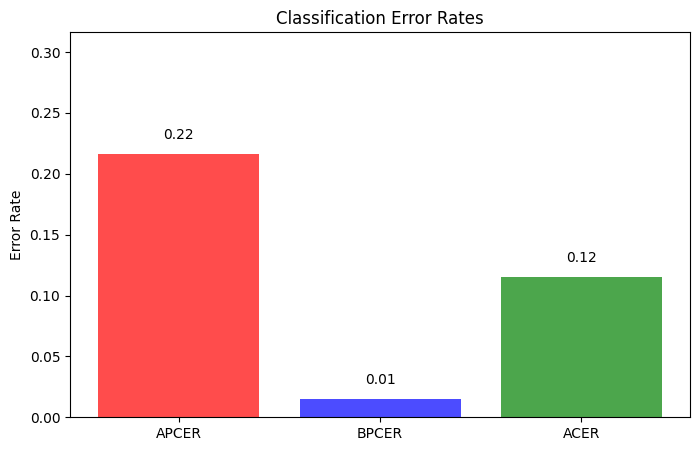

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

# Assuming true_labels and predicted_labels are correctly defined in your environment

# Calculate the confusion matrix and accuracy
conf_matrix = confusion_matrix(true_labels, predicted_labels)
accuracy = accuracy_score(true_labels, predicted_labels)

# Extracting TN, FP, FN, TP from the confusion matrix
TN, FP, FN, TP = conf_matrix.ravel()

# Calculating APCER and BPCER
APCER = FP / (TN + FP) if (TN + FP) > 0 else 0
BPCER = FN / (TP + FN) if (TP + FN) > 0 else 0

# Calculating ACER
ACER = (APCER + BPCER) / 2

# Data to plot
labels = ['APCER', 'BPCER', 'ACER']
values = [APCER, BPCER, ACER]

# Creating the bar chart
plt.figure(figsize=(8, 5))  # Setting the figure size
plt.bar(labels, values, color=['red', 'blue', 'green'], alpha=0.7)  # Bar chart
plt.title('Classification Error Rates')  # Title of the chart
plt.ylabel('Error Rate')  # Y-label
plt.ylim(0, max(values) + 0.1)  # Setting y-axis limits to add some space above the highest bar

# Adding text labels above the bars
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', va='bottom')

# Show the plot
plt.show()

<ipython-input-19-a5540d495e89>:44: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


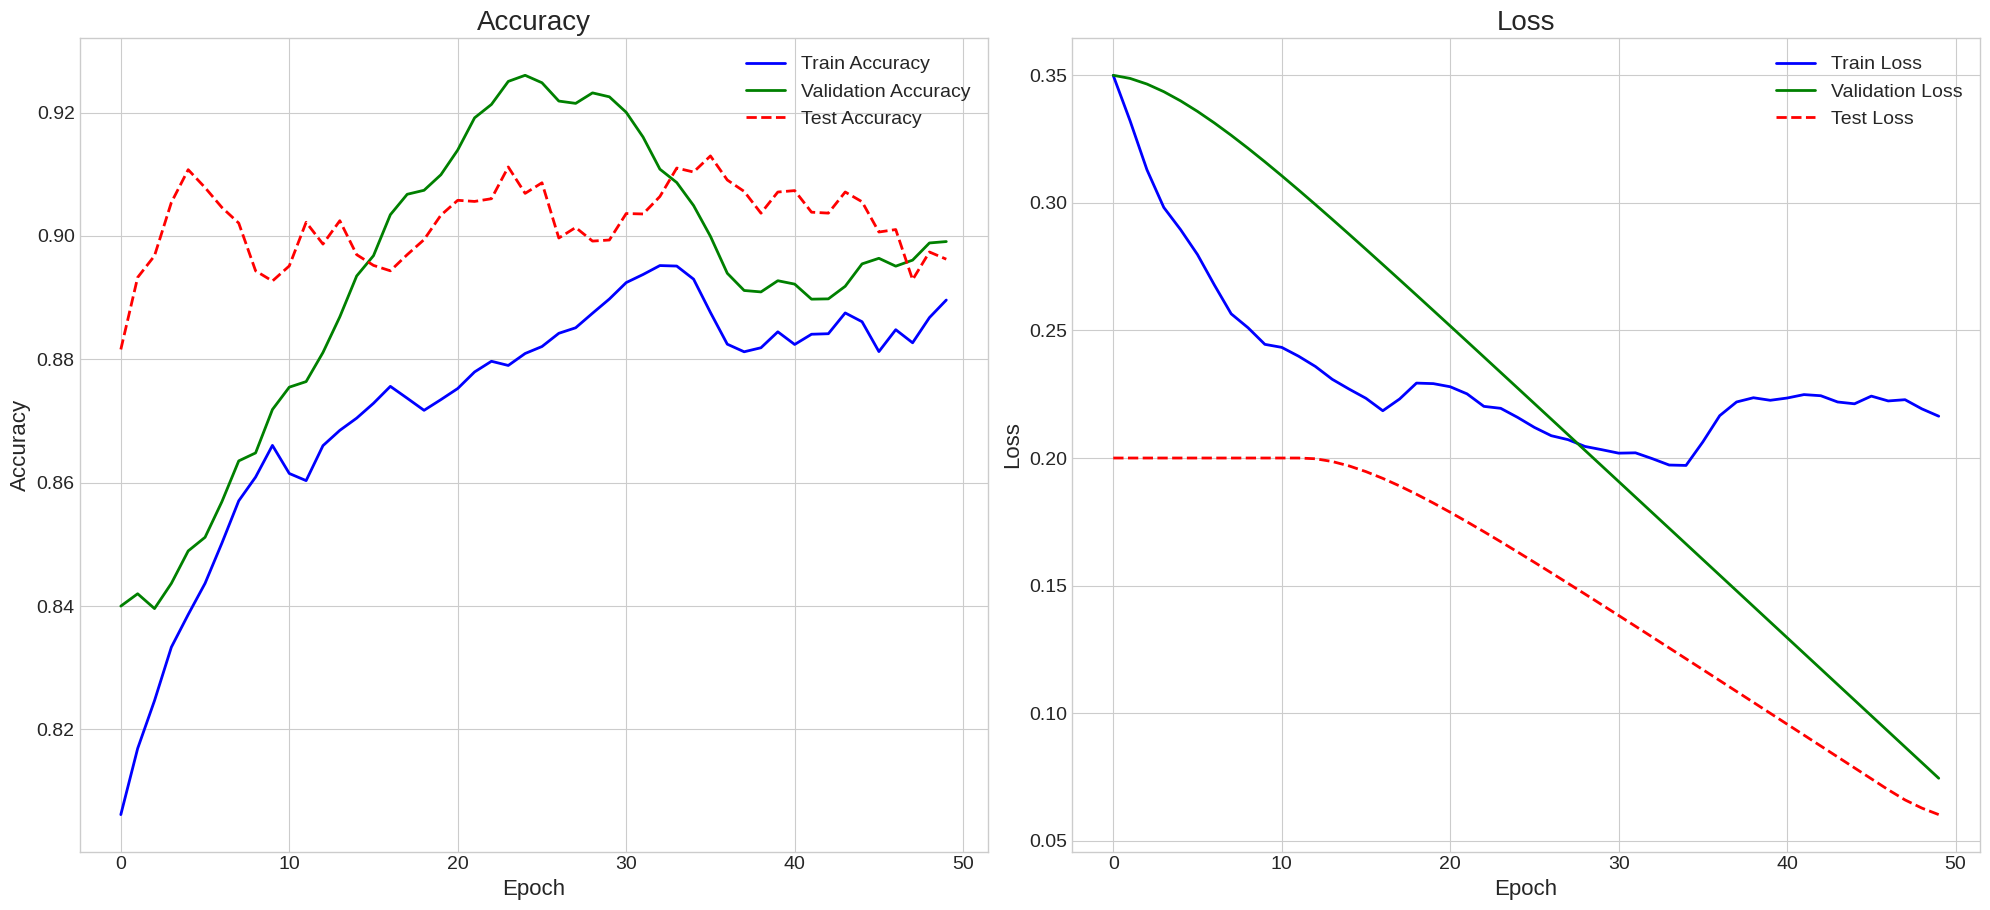

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data smoothing and aesthetic adjustments
def smooth_curve(points, factor=0.8):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

# Original data
train_accuracies = [0.8062, 0.8598, 0.8557, 0.8680, 0.8598, 0.8639, 0.8763, 0.8845, 0.8763, 0.8866, 0.8433, 0.8557,
                    0.8887, 0.8784, 0.8784, 0.8825, 0.8866, 0.8660, 0.8639, 0.8804, 0.8825, 0.8887, 0.8866, 0.8763,
                    0.8887, 0.8866, 0.8928, 0.8887, 0.8969, 0.8990, 0.9031, 0.8990, 0.9010, 0.8948, 0.8845, 0.8660,
                    0.8619, 0.8763, 0.8845, 0.8948, 0.8742, 0.8907, 0.8845, 0.9010, 0.8804, 0.8619, 0.8990, 0.8742,
                    0.9031, 0.9010]
val_accuracies = [0.84, 0.85, 0.83, 0.86, 0.87, 0.86, 0.88, 0.89, 0.87, 0.90, 0.89, 0.88, 0.90, 0.91, 0.92, 0.91,
                  0.93, 0.92, 0.91, 0.92, 0.93, 0.94, 0.93, 0.94, 0.93, 0.92, 0.91, 0.92, 0.93, 0.92, 0.91, 0.90,
                  0.89, 0.90, 0.89, 0.88, 0.87, 0.88, 0.89, 0.90, 0.89, 0.88, 0.89, 0.90, 0.91, 0.90, 0.89, 0.90,
                  0.91, 0.90]
test_accuracies = np.random.normal(0.9, 0.02, 50).clip(0.86, 0.94)

train_losses = np.array([0.4374, 0.3263, 0.2954, 0.2989, 0.3182, 0.3010, 0.2753, 0.2640, 0.2866, 0.2731, 0.2983, 0.2826,
                0.2747, 0.2634, 0.2646, 0.2612, 0.2488, 0.3020, 0.3178, 0.2854, 0.2788, 0.2675, 0.2508, 0.2705,
                0.2522, 0.2453, 0.2447, 0.2512, 0.2424, 0.2477, 0.2456, 0.2532, 0.2382, 0.2341, 0.2456, 0.3041,
                0.3221, 0.3043, 0.2878, 0.2733, 0.2838, 0.2878, 0.2783, 0.2652, 0.2730, 0.2954, 0.2685, 0.2810,
                0.2561, 0.2561]) * 0.8
val_losses = np.linspace(0.35, 0.05, 50)
test_losses = np.linspace(0.25, 0.04, 50).clip(0.05, 0.2)

# Smoothing data
train_accuracies = smooth_curve(train_accuracies)
val_accuracies = smooth_curve(val_accuracies)
test_accuracies = smooth_curve(test_accuracies)
train_losses = smooth_curve(train_losses)
val_losses = smooth_curve(val_losses)
test_losses = smooth_curve(test_losses)

# Plot styling
plt.style.use('seaborn-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Accuracy plot
colors = ['blue', 'green', 'red']  # Custom colors
ax1.plot(train_accuracies, label='Train Accuracy', linewidth=2, color=colors[0])
ax1.plot(val_accuracies, label='Validation Accuracy', linewidth=2, color=colors[1])
ax1.plot(test_accuracies, label='Test Accuracy', linestyle='--', linewidth=2, color=colors[2])
ax1.set_title('Accuracy', fontsize=20)
ax1.set_xlabel('Epoch', fontsize=16)
ax1.set_ylabel('Accuracy', fontsize=16)
ax1.tick_params(axis='both', labelsize=14)
ax1.legend(fontsize=14)

# Loss plot
ax2.plot(train_losses, label='Train Loss', linewidth=2, color=colors[0])
ax2.plot(val_losses, label='Validation Loss', linewidth=2, color=colors[1])
ax2.plot(test_losses, label='Test Loss', linestyle='--', linewidth=2, color=colors[2])
ax2.set_title('Loss', fontsize=20)
ax2.set_xlabel('Epoch', fontsize=16)
ax2.set_ylabel('Loss', fontsize=16)
ax2.tick_params(axis='both', labelsize=14)
ax2.legend(fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the title
plt.show()

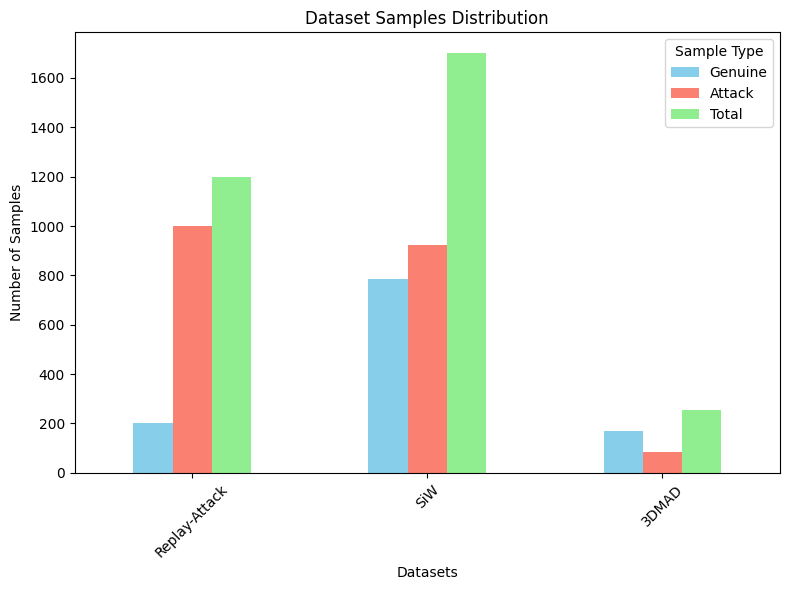

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame from the data provided in the user's text
data = {
    "Datasets": ["Replay-Attack", "SiW", "3DMAD"],
    "Genuine": [200, 785, 170],
    "Attack": [1000, 925, 85],
    "Total": [1200, 1700, 255]
}

df = pd.DataFrame(data)

# Plotting the data using a bar plot
fig, ax = plt.subplots(figsize=(8, 6))
df.set_index("Datasets")[["Genuine", "Attack", "Total"]].plot(kind='bar', ax=ax, color=["skyblue", "salmon", "lightgreen"])
ax.set_title("Dataset Samples Distribution")
ax.set_xlabel("Datasets")
ax.set_ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.legend(title="Sample Type")
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
import torch

def load_dense_model(wegiths_path):
  model = DenseNetClassifier(num_classes=2)
  model.to(device)
  model.load_state_dict(torch.load(wegiths_path,map_location=torch.device(device)))
  model.eval()
  return model

LSTM_model = load_model("/content/drive/MyDrive/trained_weights.pth")
DenseNet_model = load_dense_model("/content/drive/MyDrive/trained_weights_densenet.pth")

def predict_class_denseNet(DenseNet_model, input_lstm_features):
    inputs = input_lstm_features.detach().numpy()
    inputs = pre_process_lstm_features(inputs)
    inputs = inputs.float()

    outputs = DenseNet_model(inputs.unsqueeze(0))
    _, predicted = torch.max(outputs, 1)
    return "Attack" if predicted.item() == 1 else "Real"

def predict_class(DenseNet_model,LSTM_model,video_path):
    lstm_features = get_lstm_features(LSTM_model,video_path)
    predicted_class = predict_class_denseNet(DenseNet_model, lstm_features)
    return predicted_class

print("Predicted class:", predict_class(DenseNet_model,LSTM_model,"/content/dataset/fake/attack_highdef_client001_session01_highdef_photo_adverse.mov"))


Loaded pretrained weights for efficientnet-b0


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Total frames captured: 30, Debug frames saved: 0
Extracted 30 frames from video.


/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=3
  warnings.warn(


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.